Training Images Shape: (60000, 28, 28)
Testing Images Shape: (10000, 28, 28)
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9218 - loss: 0.2634 - val_accuracy: 0.9578 - val_loss: 0.1463
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9660 - loss: 0.1123 - val_accuracy: 0.9692 - val_loss: 0.1064
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9758 - loss: 0.0771 - val_accuracy: 0.9679 - val_loss: 0.1048
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9819 - loss: 0.0584 - val_accuracy: 0.9701 - val_loss: 0.1021
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9853 - loss: 0.0448 - val_accuracy: 0.9709 - val_loss: 0.1071
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9882 - loss: 0.0356 - val_accuracy: 0.9697 - val_loss: 0.1118
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9901 - loss: 0.0296 - val_accuracy: 0.9761 - val_loss: 0.0952
Epoch 8/10
15

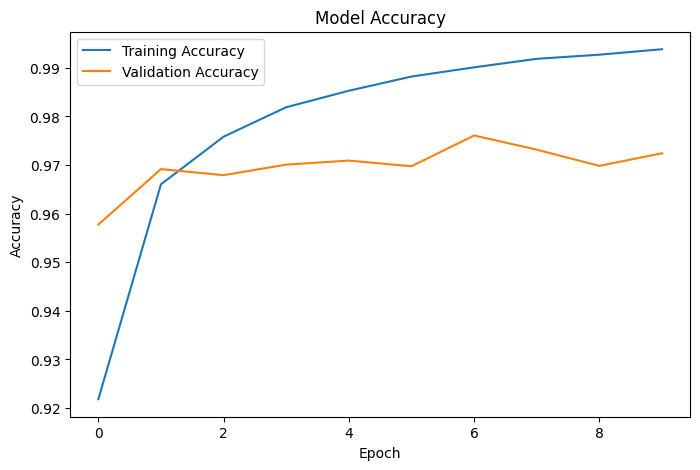

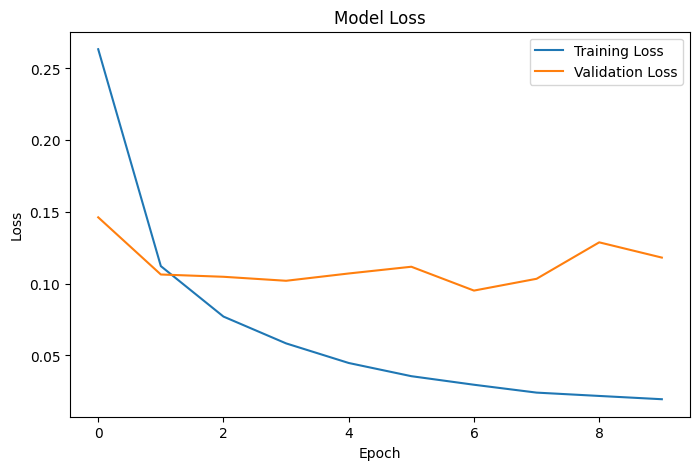

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


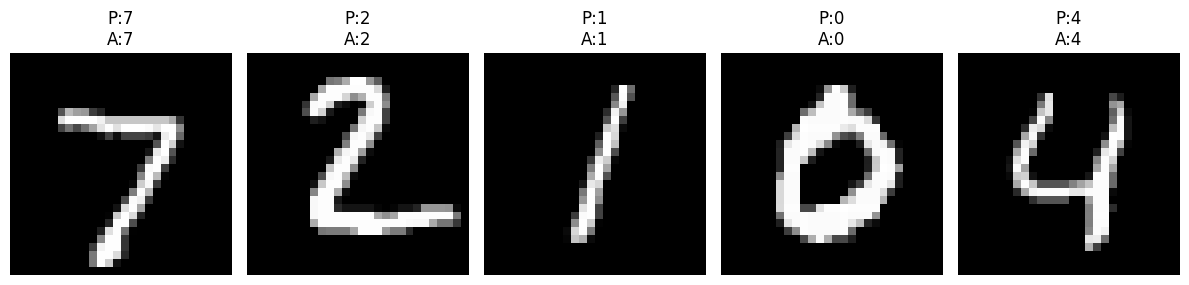

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

Single Image Prediction
Actual Digit   : 0
Predicted Digit: 0


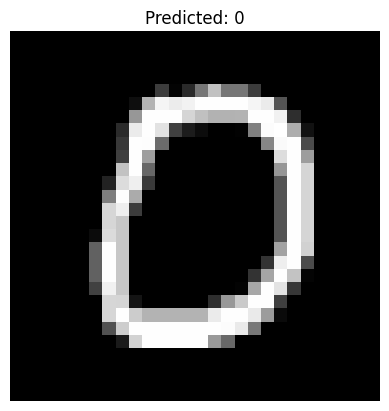

In [2]:
# ============================================================
# Task 1 - Handwritten Digit Recognition using ANN
# Dataset: MNIST
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# ============================================================
# Load MNIST Dataset
# ============================================================

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images Shape:", X_train.shape)
print("Testing Images Shape:", X_test.shape)

# ============================================================
# Data Preprocessing
# ============================================================

# Normalize pixel values (0-255 → 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# ============================================================
# Build ANN Model
# ============================================================

model = Sequential([

    # Input Layer
    Flatten(input_shape=(28, 28)),

    # Hidden Layer 1
    Dense(128, activation='relu'),

    # Hidden Layer 2
    Dense(64, activation='relu'),

    # Output Layer (10 digits: 0-9)
    Dense(10, activation='softmax')
])

# ============================================================
# Compile Model
# ============================================================

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================================
# Train Model
# ============================================================

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

# ============================================================
# Evaluate Model
# ============================================================

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Accuracy:", round(test_accuracy * 100, 2), "%")
print("Test Loss:", round(test_loss, 4))

# ============================================================
# Accuracy Graph
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# ============================================================
# Loss Graph
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# ============================================================
# Sample Predictions
# ============================================================

predictions = model.predict(X_test)

plt.figure(figsize=(12,6))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(X_test[i], cmap='gray')

    predicted_digit = np.argmax(predictions[i])

    actual_digit = y_test[i]

    plt.title(f"P:{predicted_digit}\nA:{actual_digit}")

    plt.axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# Predict Single Image
# ============================================================

sample_index = 10

sample_image = X_test[sample_index]

prediction = model.predict(
    sample_image.reshape(1, 28, 28)
)

predicted_digit = np.argmax(prediction)

print("\nSingle Image Prediction")
print("Actual Digit   :", y_test[sample_index])
print("Predicted Digit:", predicted_digit)

plt.imshow(sample_image, cmap='gray')
plt.title(f"Predicted: {predicted_digit}")
plt.axis('off')
plt.show()